# Lesson 01a: Symmetry, Equivariance and Geometric Neural Networks

**What you will learn**

- Why symmetry is the central design principle for machine learning on atomistic systems.
- The Euclidean group $E(3)$, its subgroups, $SE(3)$, $O(3)$, $SO(3)$ and what each group contains.
- The precise definitions of **invariance** and **equivariance**, with physical examples (energies are invariant; forces and dipoles are equivariant).
- A numerical demonstration that an ordinary machine learning interatomic potential (MLIP) is **not** invariant, and that data augmentation only *approximates* symmetry and it never enforces it exactly.

**Prerequisites:** Basic linear algebra and PyTorch.

In [ ]:
import sys
sys.path.insert(0, "..")  # Make course_utils importable

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.plotting import scene3d, draw_point_cloud, show3d

torch.set_default_dtype(torch.float64)  # float64: separate symmetry breaking from round-off
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## Why symmetry matters for atomistic machine learning

A molecule is unaware of the coordinate system we chose to describe it. It means, if we

- **translate** every atom by the same vector $\vec{t}$,
- **rotate** the whole system by a rotation matrix $R$, or
- **reflect** it through a mirror plane (or equivalently, invert and then, rotate it),

we get *different numbers* for the atomic positions but the *same physical system*.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>Note:</b> Reflection is subtle: it maps a molecule onto its mirror image, which for chiral molecules, genuinely generates a different object. We return to this subject in Lessons 02a and 06b. </div>

As such, physical observables must transform in a **prescribed** way under a change of coordinate frame. Writing atomic positions as rows of $x \in \mathbb{R}^{N\times 3}$ and the frame change as $x_i \mapsto R\,x_i + \vec{t}$:

| Quantity | Transformation rule | Behavior |
|---|---|---|
| total energy $E(x)$ | $E' = E$ | **invariant** (a scalar) |
| force on atom $i$, $\vec{F}_i = -\partial E/\partial \vec{x}_i$ | $\vec{F}_i' = R\,\vec{F}_i$ | **equivariant** (a vector) |
| dipole moment $\vec{\mu}$ | $\vec{\mu}' = R\,\vec{\mu}$ | **equivariant** (a vector) |
| polarizability $\alpha$ (3×3) | $\alpha' = R\,\alpha\,R^\top$ | **equivariant** (a rank-2 tensor) |

What it means in practice is that a model that does not respect these transformation rules can, for example, predict a different energy for the same molecule, seen from a different angle. Of course, such predictions would be *unphysical by construction*.

This is the exact reasoning behind the main theme of this course: building networks with built-in correct transformation behavior.

## The Euclidean group $E(3)$ and its subgroups

The frame changes mentioned above (translation, rotation, and reflection) form a **group**. A group is a set $G$ with a composition law $G \times G \to G$ such that

- (i) there is an identity $e$ with $ae = ea = a$,
- (ii) composition is associative, and
- (iii) every element $a$ has an inverse $a^{-1}$ with $a a^{-1} = a^{-1} a = e$.

The **Euclidean group** $E(3)$ is the set of all distance-preserving maps of $\mathbb{R}^3$. Every element of this group can be written as

$$ x \mapsto O\,x + \vec{t}, \qquad \qquad O \in O(3),\quad \text{and} \quad \vec{t} \in \mathbb{R}^3 , $$

where $O(3) = \{ O \in \mathbb{R}^{3\times 3} \mid O^\top O = \mathbb{1} \}$ is the group of **orthogonal matrices**: rotations ($\det O = +1$) and roto-reflections ($\det O = -1$). The subgroups we will use frequently are summarized in the following table:

| Group | Contents | Constraint |
|---|---|---|
| $SO(3)$ | proper rotations $R$ | $R^\top R = \mathbb{1}$, $\det R = +1$ |
| $O(3)$ | rotations **and** reflections/inversion | $O^\top O = \mathbb{1}$, $\det O = \pm 1$ |
| $SE(3)$ | rotations + translations | — |
| $E(3)$ | rotations, reflections, translations | — |

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>Note:</b> The inversion operation,

$$ P: \vec{x} \mapsto -\vec{x} $$

commutes with every rotation operation, so

$$ O(3) \;=\; SO(3) \times \{\mathbb{1}, P\}. $$

This means that every orthogonal matrix is either a rotation $R$ or an inverted rotation $PR = -R$. This factorization is why the e3nn package tracks a rotation label ($l$) *and* a parity label ($e$/$o$) for every feature we're going to build for our chemical systems. We will return to this subject in Lessons 01b and 02a. </div>

Let's numerically verify a few group axioms for rotations. We will use the `e3nn` package to generate random rotation matrices and `torch` to calculate the determinants.

In [2]:
# Create two random elements of SO(3)
R1, R2 = o3.rand_matrix(), o3.rand_matrix()

# Create the identity matrix (3x3)
I = torch.eye(3)

# Check the group axioms for rotations
print(f"orthogonality  |R1^T R1 - 1| = {(R1.T @ R1 - I).abs().max():.2e}")
print(f"proper         det R1        = {torch.det(R1):+.15f}")
print(f"closure        det (R1 R2)   = {torch.det(R1 @ R2):+.15f}  (product is again a rotation)")
print(f"inverse        |R1 R1^T - 1| = {(R1 @ R1.T - I).abs().max():.2e}  (inverse = transpose)")

orthogonality  |R1^T R1 - 1| = 1.39e-17
proper         det R1        = +1.000000000000000
closure        det (R1 R2)   = +1.000000000000000  (product is again a rotation)
inverse        |R1 R1^T - 1| = 2.78e-17  (inverse = transpose)


Now, lets check the improper elements: the inversion $P = -1$ and roto-reflections $-R (\text{det} = -1)$

In [3]:
# parity / inversion
P = -I

# Checks
print(f"det P        = {torch.det(P):+.0f}")
print(f"det (P R1)   = {torch.det(P @ R1):+.15f}   <-- roto-reflection")
print(f"P commutes with rotations: |P R1 - R1 P| = {(P @ R1 - R1 @ P).abs().max():.1e}")
# ... so O(3) = SO(3) x {1, P}: every O in O(3) is R or -R for some rotation R.

det P        = -1
det (P R1)   = -1.000000000000000   <-- roto-reflection
P commutes with rotations: |P R1 - R1 P| = 0.0e+00


## Invariance vs. equivariance: the definitions

For a group $G$, a function $f: X \to Y$ is **equivariant** under $G$ if

$$ f\!\left(D_X(g)\,x\right) \;=\; D_Y(g)\, f(x) \qquad \qquad \forall\, g \in G,\quad \text{and} \quad \forall\, x \in X , $$

where $D_X(g)$ and $D_Y(g)$ are the representations of the group elements $g$ acting on the vector spaces $X$ and $Y$, respectively. The $D_X(g)$ and $D_Y(g)$ matrices describe *how* the data transforms according to the group operations. The matrix representations of symmetry operations are defined in Lesson 01b. For now, think of $D_X(g)$ as an object that rotates all input coordinates, $x$ by $g$".

Now, we can define invariance and equivariance in simple terms:

- **Invariance** is a special case where $D_Y(g) = \mathbb{1}$ for all $g$: the output of transformation does not move at all. Energy as a an example of a physical quantity is invariant. When you rotate an isolated molecule (or look at it from a different angle), its energy should not change.
- **Equivariance** is more general where the output moves *along with* the input, in its own prescribed way. Forces and dipoles are equivariant quantities with respect to $D_Y(g) = R$.

Two points make equivariance the right engineering tool for building geometric neural networks for atomistic systems:

1. **Composition preserves equivariance**: if $f$ and $h$ are equivariant functions, then $h(f(D(g)x)) = h(D(g)f(x)) = D(g)\,h(f(x))$. So a deep neural network built from equivariant building blocks (layers, features etc.) is equivariant end-to-end.
2. **Learned weights are scalars**: $f(w, D_X(g)x) = D_Y(g) f(w, x)$. That is, the parameters do not transform. Symmetry constrains the architecture, not the training loop.

Let's create a toy system, a cloud of 5 point charges with a net zero charge and define two functions measuring two quantities of this system: an exactly invariant function that calculates the sum of pair-wise distances between the point charges, and an exactly equivariant function, that returns a dipole moment vector for the system. We will then check the invariance and equivariance properties of these functions, numerically.

In [4]:
# Create a system of fixed charges with zero net charge
q = torch.tensor([+1.0, +1.0, -0.5, -0.5, -1.0])

# Define a function that is invariant under rotations and translations
def f_inv(x):
    '''Sum of all pairwise distances of a point cloud x: (N, 3) -> scalar. Invariant.'''
    return torch.pdist(x).sum()

# Define a dipole moment function that is equivariant under rotations and
# translations
def f_dip(x):
    '''Dipole moment mu = sum_i q_i x_i : (N, 3) -> vector. Equivariant (needs sum q = 0
    for translation invariance -- just like a neutral molecule).'''
    return (q[:, None] * x).sum(dim=0)

# The coordinates of the point charges
x = torch.randn(5, 3)

# The translation vector
t = torch.randn(3)

# The rotation matrix
R = o3.rand_matrix()

# Transform the charge cloud with g.x = R x + t
gx = x @ R.T + t

# Check invariance and equivariance
print(f"invariance    |E(g.x) - E(x)|        = {(f_inv(gx) - f_inv(x)).abs():.2e}")
print(f"equivariance  |mu(g.x) - R mu(x)|    = {(f_dip(gx) - R @ f_dip(x)).abs().max():.2e}")
print(f"but NOT invariant: |mu(g.x) - mu(x)| = {(f_dip(gx) - f_dip(x)).abs().max():.2e}")

invariance    |E(g.x) - E(x)|        = 0.00e+00
equivariance  |mu(g.x) - R mu(x)|    = 2.22e-16
but NOT invariant: |mu(g.x) - mu(x)| = 2.18e+00


Both identities hold to $\approx 10^{-15}$ (float64 round-off error). That is what "exact symmetry" looks like, numerically. This numerical accuracy is the standard we will hold ourselves to in every layer of every network we will build during this course. We have created helper functions in the [course_utils](../course_utils) folder (e.g., `course_utils.equivariance.assert_equivariant`) to enforce this standard from Lesson 02a on.

In addition to numerical verification, it can be useful to look at our toy system of cloud charges and try to gain visual insighs from it. Our point cloud and its rotated and reflected copies are shown below.

In [5]:
# A chiral 4-point charge cloud
x0 = torch.tensor([[0.0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]])

# Center the system to remove translation
x0 = x0 - x0.mean(dim=0)

# Create a random rotation matrix to rotate the point-charge cloud
R_show = o3.rand_matrix()

# Plot the original, rotated, and inverted clouds -- drag to rotate, scroll to zoom
fig = scene3d()
draw_point_cloud(x0, fig=fig, color="C0", label="original  x")
draw_point_cloud(x0 @ R_show.T, fig=fig, color="C1", label="rotated  Rx")
draw_point_cloud(-x0, fig=fig, color="C2", label="inverted  Px = -x")
show3d(fig, title="Original, rotated, and inverted point-charge clouds")

<plotly figure: Original, rotated, and inverted point-charge clouds>

The rotated system (orange) is the same physical object as the original one (blue). The reflected version (green) is also the mirror image of the original system. Feel free to rotate the interactive 3D plot to inspect the point clouds from different angles.

## An ordinary multi-layer perceptron is not invariant

Feed the flattened coordinates $x \in \mathbb{R}^{N \times 3}$ of a cloud into a plain multi-layer perceptron $f_\theta: \mathbb{R}^{3N} \to \mathbb{R}$. Nothing in the architecture relates the outputs of the perceptron for the original charge cloud, $f_\theta(x)$, and the rotated one, $f_\theta(Rx)$. In other words, the outputs are two evaluations of an arbitrary smooth function for two unrelated points in $\mathbb{R}^{3N}$.

In [6]:
# Create a simple multi-layer perceptron (MLP) that takes flattened coordinates
# of a point cloud as input and outputs a scalar value.
def make_mlp(n_in, hidden=64):
    return torch.nn.Sequential(
        torch.nn.Linear(n_in, hidden),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden, hidden),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden, 1),
    )


# Create a random point cloud of N=5 points in 3D space and evaluate the output
# of the MLP for the original point cloud
N = 5
mlp = make_mlp(3 * N)
print(f"The number of parameters in the MLP: {sum(p.numel() for p in mlp.parameters())}")

# Create random coordinates for the 3D point cloud
x = torch.randn(N, 3)

# Evaluate the output of MLP for 256 random rotations of the point cloud and
# compute the mean, standard deviation, and spread of the outputs
preds = torch.stack([mlp((x @ o3.rand_matrix().T).flatten()) for _ in range(256)])
print(f"f(x) = {mlp(x.flatten()).item():+.4f}")
print(
    f"f(Rx) over 256 random rotations: mean {preds.mean():+.4f}, "
    f"std {preds.std():.4f}, spread {preds.max() - preds.min():.4f}"
)

The number of parameters in the MLP: 5249
f(x) = -0.1171
f(Rx) over 256 random rotations: mean -0.1249, std 0.0492, spread 0.2386


As you can see, the third line shows that the prediction of MLP wanders over a wide range of values as we merely *look at the same cloud from different angles*. If $f_\theta$ were an interatomic energy, rotating a molecule would change its predicted energy and the forces derived from it would contain torques on the whole molecule that should not exist in reality.

## Data augmentation only *approximates* symmetry

One way to mitigate the impact of the aforementioned problem is **data augmentation**: train on randomly rotated copies of the input data and hope the network learns invariance.

Let's measure how effective data augmentation can be in practice. We try to create a regression model with an exactly invariant target property, the pairwise distance sum of the input coordinates:

$$ y(x) \;=\; \sum_{i<j} \left\lVert \vec{x}_i - \vec{x}_j \right\rVert , $$

(the sum of pairwise distances — think of it as a caricature of a potential energy) with three models:

| Model | Input | Symmetry strategy |
|---|---|---|
| **A. MLP** | flattened coordinates $\in \mathbb{R}^{15}$ | none |
| **B. MLP + augmentation** | flattened coordinates, freshly rotated every step | learned (approximate) |
| **C. invariant features** | the 10 pairwise distances | **exact by construction** |

We report the test RMSE on *rotated* clouds and the **invariance error** $\max_R \lvert f(Rx) - f(x)\rvert$ over random rotations. Our dataset will consist of 5 Gaussian point-charge clouds to mimic the smearing charge clouds of individual electrons within a molecule. We use 512 and 128 test samples of point clouds for training and testing, respectively.

In [7]:
# Target = sum of pairwise distances
def target(x_batch):
    # (B, N, 3) -> (B,)
    return torch.stack([torch.pdist(x).sum() for x in x_batch])


def dists(x_batch):
    # 5 points in 3D space have 10 pairwise distances (N(N-1)/2 = 5x4/2 = 10)
    # invariant features: (B, N, 3) -> (B, 10)
    return torch.stack([torch.pdist(x) for x in x_batch])


# Set the random seed for reproducibility
torch.manual_seed(1)

# Dataset: clouds of N=5 Gaussian points;
x_train, x_test = torch.randn(512, N, 3), torch.randn(128, N, 3)
y_train, y_test = target(x_train), target(x_test)
print(
    f"train {tuple(x_train.shape)},\ntest  {tuple(x_test.shape)},\n"
    f"target mean {y_train.mean():.2f} +/- {y_train.std():.2f}"
)

train (512, 5, 3),
test  (128, 5, 3),
target mean 22.32 +/- 4.51


Let's create a training loop which returns a trained model for testing.

In [8]:
# Create the training loop. Yields trained a model for testing
def train(model, features, augment=False, steps=400, lr=1e-2, seed=2):
    """Full-batch Adam on (x_train, y_train). features: maps (B, N, 3) -> model input.
    augment=True: draw a fresh random rotation per sample at every step."""
    # Set the random seed for reproducibility
    torch.manual_seed(seed)
    # Create an Adam optimizer for the model parameters with the specified learning rate
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop for the specified number of steps
    for _ in range(steps):
        opt.zero_grad()
        xb = x_train
        if augment:
            # (B, 3, 3), one rotation per cloud
            Rb = o3.rand_matrix(len(xb))
            # x_i -> R x_i (target is unchanged)
            xb = torch.einsum("bij,bnj->bni", Rb, xb)
        loss = ((model(features(xb)).squeeze(-1) - y_train) ** 2).mean()
        loss.backward()
        opt.step()
    return model

We now use the `train` function defined above to train the three models.

In [9]:

# Flatten the point cloud coordinates to feed into the MLP- 5 point clouds with
# 3 (x,y,z) coordinates each (B, N, 3) -> (B, 15)
flat = lambda xb: xb.flatten(1)

# Train plain MLP
model_A = train(make_mlp(3 * N), flat, steps=500)

# Train augmented MLP
model_B = train(make_mlp(3 * N), flat, augment=True, steps=500)

# Train using invariant features (pairwise distances)
model_C = train(make_mlp(10), dists, steps=500)

print("training done")

training done


The models are trained. Let's now evaluate their performance on the test set.

In [10]:
@torch.no_grad()
def evaluate(model, features, n_rot=64):
    """Test RMSE on rotated clouds + invariance error max_R |f(Rx) - f(x)|."""
    f0 = model(features(x_test)).squeeze(-1)
    inv_err, rot_rmse = 0.0, []
    # Note that we are rotating the test clouds here to evaluate the
    # invariance capability of the model
    for _ in range(n_rot):
        Rb = o3.rand_matrix(len(x_test))
        # Predict the output of the model for the rotated point clouds
        fR = model(features(torch.einsum("bij,bnj->bni", Rb, x_test))).squeeze(-1)
        # Guard against numerical round-off errors using max()
        inv_err = max(inv_err, (fR - f0).abs().max().item())
        rot_rmse.append(((fR - y_test) ** 2).mean())
    return torch.stack(rot_rmse).mean().sqrt().item(), inv_err

# Evaluate the three models on the test set and print the results
results = {
    "A: MLP": evaluate(model_A, flat),
    "B: MLP + rot. aug.": evaluate(model_B, flat),
    "C: invariant feats": evaluate(model_C, dists),
}

# Print the results in a formatted table
print(f"{'Model':<22}{'Test RMSE (rotated)':>22}{'Invariance Error':>20}")
for name, (rmse, inv) in results.items():
    print(f"{name:<22}{rmse:>22.4f}{inv:>20.3e}")

Model                    Test RMSE (rotated)    Invariance Error
A: MLP                                0.9479           4.727e+00
B: MLP + rot. aug.                    0.7999           3.427e+00
C: invariant feats                    0.0475           1.421e-14


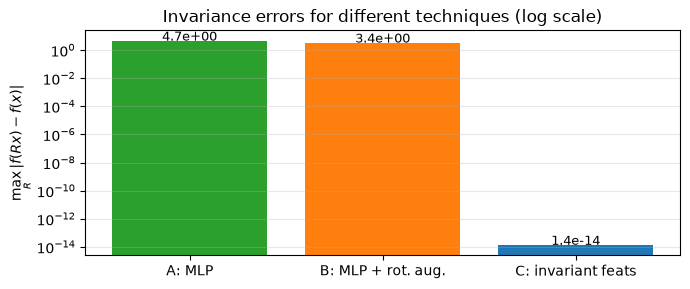

In [11]:
# Invariance error on a log scale: augmentation helps, but only
# invariance-by-construction reaches machine precision.
names = list(results)
inv_errs = [results[name][1] for name in names]

# Create a regular bar plot to visualize the invariance error for different models
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(names, inv_errs, color=["C2", "C1", "C0"])
ax.set_yscale("log")
ax.set_ylabel(r"$\max_R |f(Rx) - f(x)|$")
ax.set_title("Invariance errors for different techniques (log scale)")
for bar, v in zip(bars, inv_errs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.6, f"{v:.1e}", ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()


The resulting training and evaluation data clearly demonstrate that the data augmentation can genuinely help: model B generalizes better under rotation than A and is more invariant. But look at the *scale*: even if we train B twice as long the training budget (1000 vs. 500 steps), its worst-case invariance error will still be on the same order of magnitude as that of the vanilla MLP model. In this case, symmetry has been *learned approximately* but not *imposed*. Pushing the error down further costs ever more data and compute, and it never reaches zero. Model C, on the other hand, is exactly invariant even where it is *wrong* about the target: Because it uses invariant features (pairwise distances instead of coordinates), invariance lives in the architecture, not in the fitted weights.

For scalar targets, hand-crafted invariant features (distances, angles) can take you far. That is the SchNet/DimeNet route which we will review in Lesson 07. But to predict *equivariant* outputs (forces, dipoles, and the internal vector/tensor features that make modern potentials data-efficient), we need layers whose outputs transform correctly by construction. That requires knowing precisely what "$D_Y(g)$" can be in those cases: The theory of **group representations**, up next!

## Summary

Let us summarize what we have learned so far:

- Physical quantities transform in prescribed ways under $E(3)$: energies are **invariant**, forces/dipoles are **equivariant** vectors.
- $E(3)$ = translations + $O(3)$; $O(3) = SO(3) \times \{\mathbb{1}, P\}$ (rotations × parity); $SE(3)$ drops reflections. We have showed you how to verify important group axioms, numerically.
- Equivariance is general: $f(D_X(g)x) = D_Y(g)f(x)$; invariance is the special case $D_Y = \mathbb{1}$.
- Compositions of equivariant maps are equivariant: the license to build deep equivariant neural networks.
- An ordinary MLP which takes coordinates as input is not invariant. Rotational data augmentation can improve both accuracy and invariance of the model, but can leave the invariance error to a significant level. On the other hand, models based on invariant features become invariant by construction and are exactly invariant, even before training.

**Next:** [Lesson 01b: Group Representations](01b_group_representations.ipynb): what the $D(g)$ matrices are, why they factor into *irreducible* blocks labeled by $l = 0, 1, 2, \dots$, and how the e3nn package computes them (Wigner D-matrices).

## Exercises

**1. Translation invariance.** Model C used pairwise distances, so it is also exactly *translation* invariant. Measure the translation invariance error $\max_t |f(x + t) - f(x)|$ for models A, B and C. Which models fail, and why rotation augmentation did not help with translations?

<details><summary>Solution</summary>

```python
@torch.no_grad()
def translation_error(model, features, n=32):
    f0 = model(features(x_test)).squeeze(-1)
    return max((model(features(x_test + torch.randn(3))).squeeze(-1) - f0)
               .abs().max().item() for _ in range(n))

for name, (m, ft) in {"A": (model_A, flat), "B": (model_B, flat),
                      "C": (model_C, dists)}.items():
    print(name, f"{translation_error(m, ft):.3e}")
```

A and B both fail badly: augmentation was performed with rotations only, so nothing taught the MLPs about translations. Each symmetry operation must be applied to data for augmentation, independently, and each is only ever learned approximately. Model C is exact because pairwise distances are independent of the origin. </details>

**2. Reflections and chirality.** Model B was augmented with *proper* rotations only (`o3.rand_matrix` has $\det R = +1$). Measure its invariance error under the inversion $x \mapsto -x$ and compare the resulting testing error with its rotational counterpart from the lesson. Is the target $y(x)$ inversion-invariant?

<details><summary>Solution</summary>

```python
@torch.no_grad()
def inversion_error(model, features):
    f0 = model(features(x_test)).squeeze(-1)
    return (model(features(-x_test)).squeeze(-1) - f0).abs().max().item()

print("B under inversion:", f"{inversion_error(model_B, flat):.3e}")
```

The target *is* inversion-invariant (distances don't change under inversion, $x \to -x$), but the error under inversion is markedly larger than under rotations: the model was never shown inverted clouds. The augmentation only covers the group elements/operations you sample. (In $O(3)$ language: B was trained toward $SO(3)$ invariance, not $O(3)$.) </details>

**3. Composition (pen & paper).** Let $f: X \to Y$ and $h: Y \to Z$ be equivariant, i.e. $f(D_X(g)x) = D_Y(g)f(x)$ and $h(D_Y(g)y) = D_Z(g)h(y)$. Show that the composition, $h \circ f$, is equivariant, and conclude that a network of stacked equivariant layers with an invariant final layer is invariant end-to-end.

<details><summary>Solution</summary>

$h(f(D_X(g)x)) = h(D_Y(g) f(x)) = D_Z(g)\, h(f(x))$ — first equality uses equivariance of $f$, second uses equivariance of $h$ with $y = f(x)$. By induction any finite stack is equivariant; if the last map has $D_Z(g) = \mathbb{1}$ (an invariant readout, e.g. a sum of scalar features), the whole network is invariant. </details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)